Task 1 : Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
from numpy import array

import keras as keras
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import plot_model
from keras.layers import Softmax as Softmax
from keras.backend import argmax as ToClass

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from sklearn.tree import export_text
from sklearn.tree import plot_tree
from sklearn.cluster import KMeans 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
import time as time
from statistics import mean as mean

columns = [ "ID",
"senior",
"tenure",
"streaming",
"contract",
"payMethod",
"monthlyCharges",
"totalCharges",
"churn"]

df = pd.read_csv('http://raptor.kent.ac.uk/~lb514/Data/CustomerChurn.csv', names = columns)

df.info()
df.head(5)

2026-01-19 10:06:59.476576: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-19 10:06:59.476691: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-19 10:06:59.476729: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-19 10:07:00.814611: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              7043 non-null   object 
 1   senior          7040 non-null   float64
 2   tenure          7021 non-null   float64
 3   streaming       7042 non-null   object 
 4   contract        7041 non-null   object 
 5   payMethod       7042 non-null   object 
 6   monthlyCharges  7041 non-null   float64
 7   totalCharges    7042 non-null   object 
 8   churn           7043 non-null   object 
dtypes: float64(3), object(6)
memory usage: 495.3+ KB


,ID,senior,tenure,streaming,contract,payMethod,monthlyCharges,totalCharges,churn
0,7590-VHVEG,0.0,1.0,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,0.0,34.0,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,0.0,2.0,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,0.0,45.0,No,One year,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,0.0,2.0,No,Month-to-month,Electronic check,70.70,151.65,Yes


Task 2 : Initial preprocessing (basic cleaning) & split

In [2]:
#Preprocessing / Data Cleaning
print("Initial shape:", df.shape)

#Removing irrelevant columns
#ID is not useful to help predict customer spending, as it is an identifier for customer within the dataset
df = df.drop(columns=['ID'])

#Converting datatypes
#Need to convert 'totalCharges' from object to float
df['totalCharges'] = pd.to_numeric(df['totalCharges'], errors='coerce')

#Encoding categorical variables to numeric
#Given that 'churn' is an object, and we are looking to run models using numeric encoding, the variable needs to be converted for ease of processing for decision trees/regression models
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

#I ORIGINALLY activley chose not to do anything wiht missing values at this stage, instead opting to recode them after splitting into train/test subsets.
#I did this to avoid data leakage from the main dataset into the test data
#Eventaully, given continuous errors in Task 5, I had to restart and drop missing values from 'senior' in order to get any proper outputs in that task
df = df.dropna(subset=['senior'])
print(df.isnull().sum())

df.info()

Initial shape: (7043, 9)
senior             0
tenure            19
streaming          0
contract           0
payMethod          0
monthlyCharges     0
totalCharges      11
churn              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 7040 entries, 0 to 7041
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   senior          7040 non-null   float64
 1   tenure          7021 non-null   float64
 2   streaming       7040 non-null   object 
 3   contract        7040 non-null   object 
 4   payMethod       7040 non-null   object 
 5   monthlyCharges  7040 non-null   float64
 6   totalCharges    7029 non-null   float64
 7   churn           7040 non-null   int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 495.0+ KB


In [3]:
#Splitting data into training and test sets
x = df.drop(columns=['totalCharges'])
y = df['totalCharges']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=15)

print(x_train.shape)
print(y_train.shape)

(5632, 7)
(5632,)


Task 3: Further preprocessing (post-split)

In [4]:
#Dealing with missing values in two steps for x_train and x_test dataframes
#1: Instead of dropping them from the dataset, I chose to fill the NaNs/nulls with the mean of the column of the x_train dataset in order to better preserve varibles / avoid losing observations
#(i.e. not dropping full rows that may be missing a certain value in any given cell whereby the rest of the row is useable / useful)

#Use the mean of x_train to fill in missing values for x_train
for col in ['tenure', 'monthlyCharges']:
    x_train[col].fillna(x_train[col].mean(), inplace=True)

#Use the mean of x_train to fill in missing values for x_test
for col in ['tenure', 'monthlyCharges']:
    x_test[col].fillna(x_train[col].mean(), inplace=True)

#Direct repeating of the above, but for y_train and y_test dataframes
#Use the mean of y_train to fill in missing values for y_train
y_train = y_train.fillna(y_train.mean())

#Use the mean of y_train to fill in missing values for y_test
y_test = y_test.fillna(y_train.mean())

print(x_train.shape)
print(y_train.shape)

(5632, 7)
(5632,)


In [5]:
print("X-Train Null:\n", x_train.isnull().sum())
print("X-Test Null:\n", x_test.isnull().sum())
print("Y-Train Null:\n", y_train.isnull().sum())
print("Y-Test Null:\n", y_test.isnull().sum())

X-Train Null:
 senior            0
tenure            0
streaming         0
contract          0
payMethod         0
monthlyCharges    0
churn             0
dtype: int64
X-Test Null:
 senior            0
tenure            0
streaming         0
contract          0
payMethod         0
monthlyCharges    0
churn             0
dtype: int64
Y-Train Null:
 0
Y-Test Null:
 0


In [27]:
#Splitting numerical and categorical varibles into separate groupings
numeric_features = ['senior', 'tenure', 'monthlyCharges', 'churn']
categorical_features = ['streaming', 'contract', 'payMethod']

#Create OneHotEncoder
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

#Select, fit, and transform categorical data within the train set only
x_train_processed = enc.fit_transform(x_train[categorical_features])

#Transform only on test set
x_test_processed = enc.transform(x_test[categorical_features])

print(x_test_processed)

[[0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 1.]
 ...
 [1. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 1. 0.]
 [1. 0. 0. ... 1. 0. 0.]]


In [12]:
# Convert encoded arrays back to DataFrames with proper column names
x_train_cat = pd.DataFrame(
    x_train_processed,
    columns=enc.get_feature_names_out(categorical_features),
    index=x_train.index
)

x_test_cat = pd.DataFrame(
    x_test_processed,
    columns=enc.get_feature_names_out(categorical_features),
    index=x_test.index
)

# Get numeric part as DataFrame
x_train_num = x_train[numeric_features]
x_test_num  = x_test[numeric_features]

# Concatenate numeric + categorical parts into final DataFrames
x_train_final = pd.concat([x_train_num, x_train_cat], axis=1)
x_test_final  = pd.concat([x_test_num, x_test_cat], axis=1)

In [13]:
print(x_train_final.shape)
print(y_train.shape)

(5632, 14)
(5632,)


Task 4: Decision Tree Regression

In [14]:
#Step 1: initialize and train the DTR model, using the stated constraint for random key
dt_reg = DecisionTreeRegressor(random_state=15)
dt_reg.fit(x_train_final, y_train)

DecisionTreeRegressor(random_state=15)

In [15]:
#Step 2: Predict on test data
y_pred = dt_reg.predict(x_test_final)

#Calculate r-squared value using the prediction
r2 = r2_score(y_test, y_pred)
print("R-squared score on Decision Tree Regressor set:", r2)

#With an r-squared of 0.997, we can denote a strong correlation between the actual vs predicted values. 
#Though this may also be a symptom over over-fitting the model, with the tree memorizing trainind data

R-squared score on Decision Tree Regressor set: 0.9965952523584428


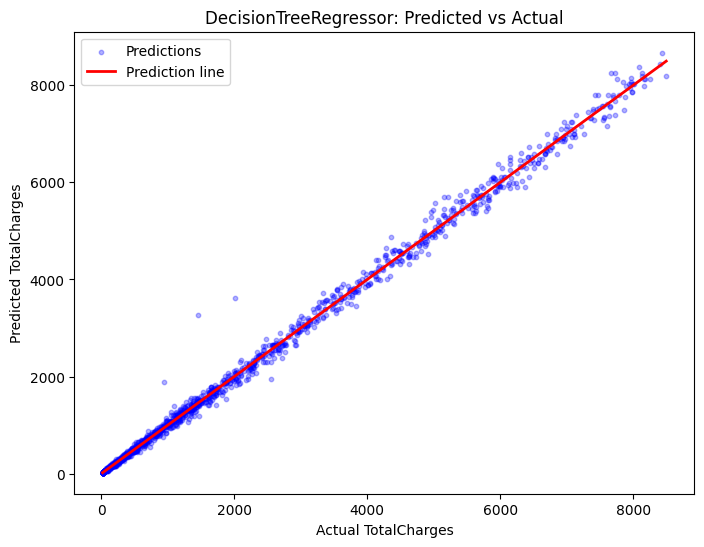

In [16]:
#Step 3: Plot predicted vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, s=10, alpha=0.3, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r-', lw=2, label='Prediction line')
plt.xlabel("Actual TotalCharges")
plt.ylabel("Predicted TotalCharges")
plt.title("DecisionTreeRegressor: Predicted vs Actual")
plt.legend()
plt.show()

Task 5: Neural Network Regression (Keras)

In [17]:
#Normalize numeric features using StandardScaler (fit on train, transform both)
scaler = StandardScaler()

x_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(x_train_num),
    columns=x_train_num.columns,
    index=x_train_num.index
)
x_test_num_scaled = pd.DataFrame(
    scaler.transform(x_test_num),
    columns=x_test_num.columns,
    index=x_test.index
)

# Final feature sets: scaled numeric + one-hot categorical
x_train_final2 = pd.concat([x_train_num_scaled, x_train_cat], axis=1)
x_test_final2  = pd.concat([x_test_num_scaled,  x_test_cat], axis=1)

In [18]:
#Build ANN
model = Sequential()

#First hidden layer: 64 neurons, ReLU
model.add(Dense(64, activation='relu', input_dim=x_train_final.shape[1]))

#Second hidden layer: 32 neurons, ReLU
model.add(Dense(32, activation='relu'))

#Output layer: 1 neuron, linear activation for regression
model.add(Dense(1, activation='linear'))

# Compile model
model.compile(optimizer='adam', loss='mse')

# Justification:
# - Two hidden layers balance complexity and generalization
# - ReLU captures non-linear relationships
# - Linear output is correct for regression
# - Adam optimizer + MSE loss is standard for regression tasks

In [19]:
history = model.fit(
    x_train_final2, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=32,
    verbose=False)

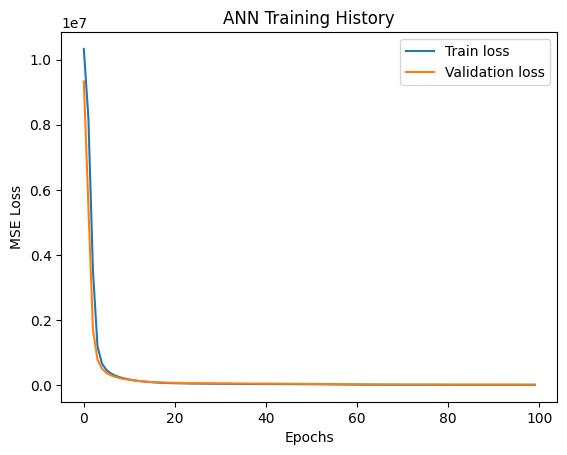

In [20]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('ANN Training History')
plt.legend()
plt.show()

In [21]:
y_pred_ann = model.predict(x_test_final2).ravel()
r2_ann = r2_score(y_test, y_pred_ann)
print("R-squared score (ANN):", r2_ann)

44/44 [==============================] - 0s 1ms/step
R-squared score (ANN): 0.9958841975744822


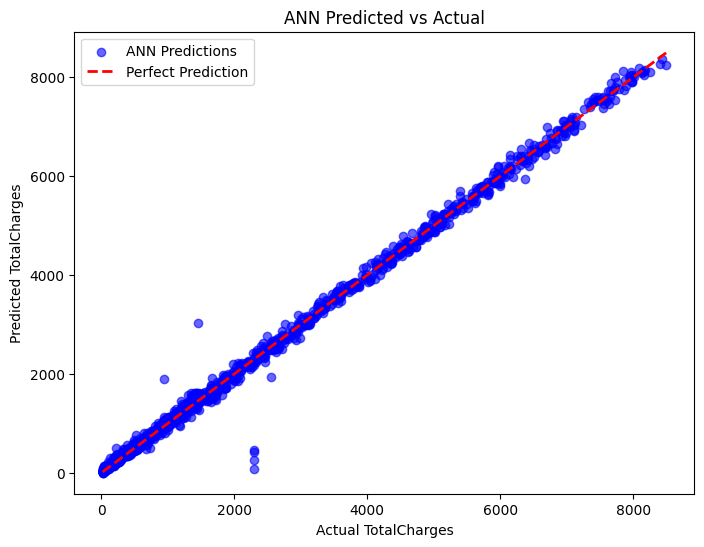

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_ann, alpha=0.6, color='blue', label='ANN Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual TotalCharges')
plt.ylabel('Predicted TotalCharges')
plt.title('ANN Predicted vs Actual')
plt.legend()
plt.show()

Final Notes

I tried to do what I could to keep the train/test data separated by cleaning later in the process. I continuously ran into issues with missing/null data that greatly impacted Task 5: ANN. In the interest of not going crazy trying to figure out correcting the issue (i.e. 'senior' missing two values in x_train; one in x_test; and zero in y_train. This skewed everything else I originally planned to do, causing some unnecessary/undesired data leakage and causing the r-squared coefficients to be nearly identical, showing a form of overfitting into the built models (referring to both DTR and ANN). I can continue playing around with how to fix it, but given the countless hours I've already gotten overtly frustrated with zero resolution, I am choosing to finalize and submmit the mini-practical as-is. 

Please understand my frustration and accept this explanation, knowing it _should_ do little to impact the evaluation of my work. Any feedback you can provide about how to fix this issue from occuring down the road, I would greatly appreciate it. Many thanks!